# Logistic Regression

**Learning Objectives:**
- Apply Logistic Regression for binary classification
- Understand the importance of feature scaling
- Use GridSearchCV to tune the regularization parameter C
- Use Recursive Feature Elimination (RFE) for feature selection

**Dataset:** Pima Indians Diabetes

In [3]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, precision_score, confusion_matrix
from sklearn.preprocessing import MinMaxScaler
from sklearn.feature_selection import RFE
import numpy as np

seed = 42

In [4]:
df = pd.read_csv('data/diabetes.csv')

In [5]:
df.head()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148,72,35,0,33.6,0.627,50,1
1,8,183,64,0,0,23.3,0.672,32,1
2,0,137,40,35,168,43.1,2.288,33,1
3,3,78,50,32,88,31.0,0.248,26,1
4,2,197,70,45,543,30.5,0.158,53,1


In [6]:
print(f'Shape: {df.shape}')
print(f'Class distribution:\n{df["Outcome"].value_counts()}')

Shape: (568, 9)
Class distribution:
Outcome
0    300
1    268
Name: count, dtype: int64


In [7]:
df.dtypes

Pregnancies                   int64
Glucose                       int64
BloodPressure                 int64
SkinThickness                 int64
Insulin                       int64
BMI                         float64
DiabetesPedigreeFunction    float64
Age                           int64
Outcome                       int64
dtype: object

In [8]:
print(f'Has nulls: {df.isnull().values.any()}')

Has nulls: False


<Axes: >

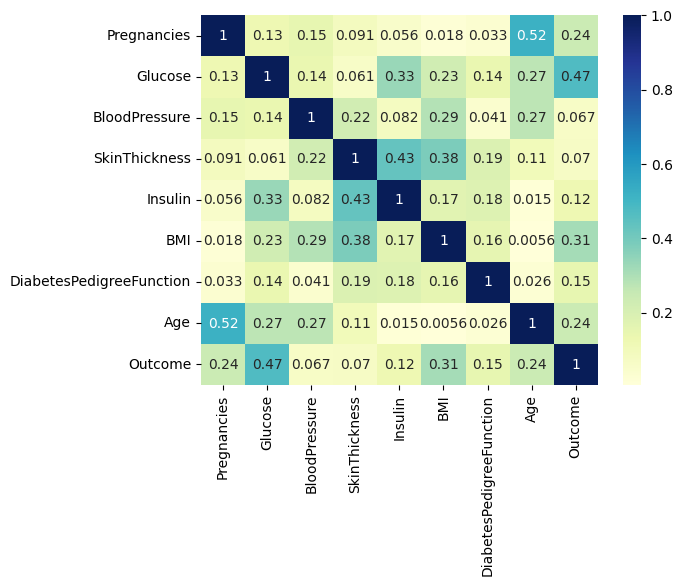

In [9]:
sns.heatmap(df.corr().abs(), annot=True, cmap='YlGnBu')

### Baseline Model (No Scaling)

Logistic Regression uses gradient descent — feature scale matters for convergence.

In [10]:
train_set, test_set = train_test_split(df, test_size=0.2, random_state=seed)

X_train = train_set.drop(['Outcome'], axis=1)
y_train = train_set['Outcome']
X_test = test_set.drop(['Outcome'], axis=1)
y_test = test_set['Outcome']

In [11]:
lr = LogisticRegression(random_state=seed, max_iter=200).fit(X_train, y_train)
y_preds = lr.predict(X_test)
print(f'Accuracy: {accuracy_score(y_test, y_preds):.4f}')
print(f'Precision: {precision_score(y_test, y_preds):.4f}')

Accuracy: 0.7105
Precision: 0.7647


### With Feature Scaling

Scale features to [0,1] so the model converges faster and treats features equally.

In [12]:
scaler = MinMaxScaler()
features_names = X_train.columns

X_train = scaler.fit_transform(X_train)
X_train = pd.DataFrame(X_train, columns=features_names)

X_test = scaler.transform(X_test)
X_test = pd.DataFrame(X_test, columns=features_names)

In [13]:
X_train.describe()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age
count,454.000000,454.000000,454.000000,454.000000,454.000000,454.000000,454.000000,454.000000
mean,0.232185,0.628351,0.610750,0.324418,0.099647,0.480051,0.172740,0.218722
std,0.202204,0.160627,0.173271,0.251687,0.145522,0.117010,0.150056,0.203120
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,0.058824,0.512563,0.561404,0.000000,0.000000,0.408718,0.070986,0.050000
50%,0.176471,0.613065,0.631579,0.365079,0.036052,0.476900,0.124893,0.150000
75%,0.352941,0.728643,0.701754,0.507937,0.153664,0.546572,0.241567,0.350000
max,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000


In [14]:
lr = LogisticRegression(random_state=seed, max_iter=200).fit(X_train, y_train)
y_preds = lr.predict(X_test)
print(f'Accuracy: {accuracy_score(y_test, y_preds):.4f}')
print(f'Precision: {precision_score(y_test, y_preds):.4f}')

Accuracy: 0.7018
Precision: 0.7708


In [26]:
# TODO: standardize features and compare results with StandardScaler.
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
features_names = X_train.columns    

X_train = scaler.fit_transform(X_train)
X_train = pd.DataFrame(X_train, columns=features_names)

X_test = scaler.transform(X_test)
X_test = pd.DataFrame(X_test, columns=features_names)

lr = LogisticRegression(random_state=seed, max_iter=200).fit(X_train, y_train)
y_preds = lr.predict(X_test)
print(f'Accuracy: {accuracy_score(y_test, y_preds):.4f}')
print(f'Precision: {precision_score(y_test, y_preds):.4f}')

Accuracy: 0.7105
Precision: 0.7647


### Tuning C (Inverse Regularization)

Smaller C = stronger regularization (prevents overfitting). Larger C = less regularization. We tune via GridSearchCV.

In [15]:
lr = LogisticRegression(random_state=seed, max_iter=200)
parameters = {'C': [0.01, 0.1, 1, 10, 100]}

clf = GridSearchCV(lr, parameters, cv=5).fit(X_train, y_train)

In [16]:
print(f'Best C: {clf.best_params_}')
print(f'Best CV score: {clf.best_score_:.4f}')

Best C: {'C': 10}
Best CV score: 0.7379


In [17]:
lr = LogisticRegression(random_state=seed, max_iter=200, C=10).fit(X_train, y_train)
y_preds = lr.predict(X_test)
print(f'Test accuracy: {accuracy_score(y_test, y_preds):.4f}')

Test accuracy: 0.7105


Text(50.722222222222214, 0.5, 'Actual')

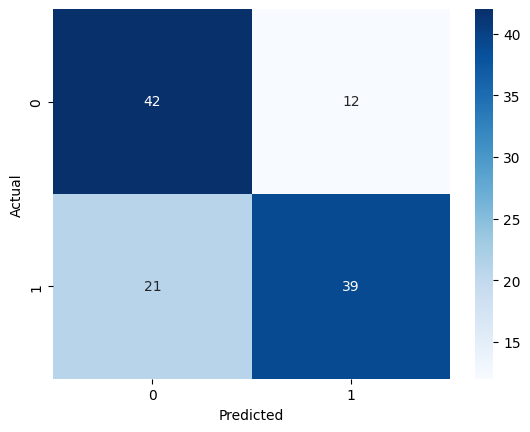

In [18]:
cm = confusion_matrix(y_test, y_preds)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.xlabel('Predicted')
plt.ylabel('Actual')

### Coefficient Interpretation

Positive coefficient → feature increases probability of class 1 (diabetes). Negative → decreases probability.

In [19]:
coefs = pd.DataFrame(lr.coef_[0], index=X_train.columns, columns=['Coef'])
coefs.sort_values(by='Coef', ascending=False)

,Coef
Glucose,6.715114
BMI,5.821670
Pregnancies,2.383973
DiabetesPedigreeFunction,1.049426
Age,0.794354
SkinThickness,-0.351286
Insulin,-0.616820
BloodPressure,-1.314975


Glucose, BMI, and Age are the strongest positive predictors of diabetes.

### Feature Selection with RFE

Recursive Feature Elimination: recursively removes the least important features.

In [20]:
lr = LogisticRegression(random_state=seed)
rfe = RFE(lr, n_features_to_select=6).fit(X_train, y_train)

In [21]:
df_features = pd.DataFrame({'names': X_train.columns, 'rank': rfe.ranking_})
df_features.sort_values('rank')

,names,rank
0,Pregnancies,1
1,Glucose,1
2,BloodPressure,1
5,BMI,1
7,Age,1
6,DiabetesPedigreeFunction,1
3,SkinThickness,2
4,Insulin,3


In [22]:
lr = LogisticRegression(random_state=seed).fit(X_train[features_names[rfe.support_]], y_train)
y_preds = lr.predict(X_test[features_names[rfe.support_]])
print(f'Accuracy with 6 features: {accuracy_score(y_test, y_preds):.4f}')
print(f'Precision with 6 features: {precision_score(y_test, y_preds):.4f}')

Accuracy with 6 features: 0.7018
Precision with 6 features: 0.7708


Similar accuracy with 6 features vs all 8 — simpler model, similar performance.

### Parameter Notes — LogisticRegression

| Parameter | Default | Description | Typical Range |
|-----------|---------|-------------|---------------|
| `C` | 1.0 | Inverse regularization strength. Smaller → stronger regularization. | 0.001–100 |
| `penalty` | 'l2' | Regularization type: 'l1' (sparsity), 'l2' (standard), 'elasticnet'. | 'l1', 'l2', 'elasticnet', None |
| `solver` | 'lbfgs' | Optimization algorithm. 'saga' supports all penalties. | 'lbfgs', 'liblinear', 'saga', 'newton-cg' |
| `max_iter` | 100 | Max iterations. Increase if convergence warning. | 100–1000 |
| `multi_class` | 'auto' | Strategy: 'ovr' (one-vs-rest), 'multinomial' (softmax). | 'auto', 'ovr', 'multinomial' |
| `class_weight` | None | 'balanced' auto-adjusts for class imbalance. | None, 'balanced' |
| `tol` | 0.0001 | Tolerance for stopping criteria. | 1e-4–1e-3 |

**Important:** Always scale features before Logistic Regression — it uses gradient descent internally.

## Exercise — Sonar Dataset

Apply Logistic Regression to the Sonar (Mines vs. Rocks) dataset.
Source: https://archive.ics.uci.edu/ml/datasets/Connectionist+Bench+(Sonar,+Mines+vs.+Rocks)

In [23]:
df_sonar = pd.read_csv('data/sonar_data.csv', header=None)
df_sonar.head()

,0,1,2,3,4,5,6,7,8,9,...,51,52,53,54,55,56,57,58,59,60
0,0.0200,0.0371,0.0428,0.0207,0.0954,0.0986,0.1539,0.1601,0.3109,0.2111,...,0.0027,0.0065,0.0159,0.0072,0.0167,0.0180,0.0084,0.0090,0.0032,R
1,0.0453,0.0523,0.0843,0.0689,0.1183,0.2583,0.2156,0.3481,0.3337,0.2872,...,0.0084,0.0089,0.0048,0.0094,0.0191,0.0140,0.0049,0.0052,0.0044,R
2,0.0262,0.0582,0.1099,0.1083,0.0974,0.2280,0.2431,0.3771,0.5598,0.6194,...,0.0232,0.0166,0.0095,0.0180,0.0244,0.0316,0.0164,0.0095,0.0078,R
3,0.0100,0.0171,0.0623,0.0205,0.0205,0.0368,0.1098,0.1276,0.0598,0.1264,...,0.0121,0.0036,0.0150,0.0085,0.0073,0.0050,0.0044,0.0040,0.0117,R
4,0.0762,0.0666,0.0481,0.0394,0.0590,0.0649,0.1209,0.2467,0.3564,0.4459,...,0.0031,0.0054,0.0105,0.0110,0.0015,0.0072,0.0048,0.0107,0.0094,R


In [24]:
print(f'Shape: {df_sonar.shape}')
print(f'Target distribution:\n{df_sonar[60].value_counts()}')

Shape: (208, 61)
Target distribution:
60
M    111
R     97
Name: count, dtype: int64


60 features, binary target (R=Rock, M=Mine). Steps:
1. Encode target (R→0, M→1)
2. Scale features
3. Train Logistic Regression
4. Tune C with GridSearchCV
5. Evaluate with accuracy and precision

In [25]:
# TODO: encode target, scale features, train Logistic Regression, tune C